In [1]:
from Bio import AlignIO
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import pandas as pd
import seaborn as sns
from statsmodels.sandbox.stats.multicomp import multipletests
np.random.seed(7)

In [2]:
sns.set_theme(context="notebook", style='whitegrid')

In [3]:
def compute_identity(alignment):
    """Compute the per-position identity score for a single alignment block."""
    seqs = [str(record.seq).upper() for record in alignment]  # extract the sequences from the alignment block and convert to uppercase
    seq_len = len(seqs[0])  
    num_seqs = len(seqs)  
    identity = [0] * seq_len 

    for i in range(seq_len):
        # count the frequency of each nucleotide and insertions at this position
        freq = {'A': 0, 'C': 0, 'G': 0, 'T': 0, '-': 0}
        for seq in seqs:
            freq[seq[i]] += 1
        # compute the identity score at this position
        identity[i] = max(freq.values()) / num_seqs

    return identity

In [4]:
def plot_score(score: np.array, sequence: np.array, gates: list, width: int, title: str, ylabel: str, error_kind: str):

    gapeless_bool_idx = sequence!="-"
    # fill float idx array with non linear indexes and fill gaps with linear interpolation
    l = len(sequence[gapeless_bool_idx])
    sparse_float_idx = np.zeros(len(sequence), dtype=float)
    sparse_float_idx[gapeless_bool_idx] = np.arange(1, l+1, dtype=float)
    mask = sparse_float_idx==0
    sparse_float_idx[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), sparse_float_idx[~mask])

    window_scores = []
    max_l = len(score)

    for l, r in gates:
        window_idx = (sparse_float_idx>=l) & (sparse_float_idx<=r-1)
        dense_int_idx = np.arange(1, len(sequence)+1, dtype=int)
        l_id = dense_int_idx[window_idx][0]
        left_edge = max(0, l_id - width)
        right_edge = min(max_l, l_id + width)
        if l_id < width or max_l < l_id + width:
            continue
        window_huge = score[left_edge:right_edge]
        window_scores += [window_huge]

    window_scores = np.array(window_scores)


    plt.figure(figsize=(15, 5))
    sns.lineplot(x=np.tile(np.arange(-width, width), len(window_scores)), y=window_scores.ravel(), 
            estimator=np.mean, errorbar=error_kind, legend='full')
    plt.xlabel('Nucleotides from the site start')
    plt.ylabel(ylabel)
    plt.title(title)

In [5]:
def get_random_gates(seq_len: int, orig_gates: list, width: int, n: int):
    """ 
    Get n random gates in the sequence without replacement & without intersection with the gates
    """
    rest_seq = np.arange(seq_len)
    index_delete = [0, np.arange(width)]
    index_delete += [np.arange(seq_len-width, seq_len)]

    orig_gates = np.array(orig_gates)
    for i in orig_gates[:, 0]:
        index_delete += [np.arange(i-2*width, i+2*width)]
    index_delete = np.hstack(index_delete)
    rest_seq = np.delete(rest_seq, index_delete)
    random_gates = np.random.choice(rest_seq, n, replace=False)
    random_gates = np.array([random_gates, random_gates+4]).T
    return random_gates.tolist()

In [6]:
def mean_score_per_site(score: np.array, sequence: np.array, gates: list, width: int):
    gapeless_bool_idx = sequence!="-"
    # fill float idx array with non linear indexes and fill gaps with linear interpolation
    l = len(sequence[gapeless_bool_idx])
    sparse_float_idx = np.zeros(len(sequence), dtype=float)
    sparse_float_idx[gapeless_bool_idx] = np.arange(1, l+1, dtype=float)
    mask = sparse_float_idx==0
    sparse_float_idx[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), sparse_float_idx[~mask])

    window_scores = []
    max_l = len(score)

    for l, r in gates:
        window_idx = (sparse_float_idx>=l) & (sparse_float_idx<=r-1)
        dense_int_idx = np.arange(1, len(sequence)+1, dtype=int)
        l_id = dense_int_idx[window_idx][0]
        left_edge = max(0, l_id - width)
        right_edge = min(max_l, l_id + width)
        if l_id < width or max_l < l_id + width:
            continue
        window_huge = score[left_edge:right_edge]
        
        window_scores += [window_huge]

    window_scores = np.array(window_scores)
    return np.mean(window_scores, axis=1)

In [7]:
def split_score_distribution(score: np.array, sequence: np.array, gates: list, width: int):

    gapeless_bool_idx = sequence!="-"
    # fill float idx array with non linear indexes and fill gaps with linear interpolation
    l = len(sequence[gapeless_bool_idx])
    sparse_float_idx = np.zeros(len(sequence), dtype=float)
    sparse_float_idx[gapeless_bool_idx] = np.arange(1, l+1, dtype=float)
    mask = sparse_float_idx==0
    sparse_float_idx[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), sparse_float_idx[~mask])

    window_scores = []
    rest_scores = []

    max_l = len(score)
    prev_r = 0

    for l, r in gates:
        window_idx = (sparse_float_idx>=l) & (sparse_float_idx<=r-1)
        dense_int_idx = np.arange(1, len(sequence)+1, dtype=int)
        l_id = dense_int_idx[window_idx][0]
        left_edge = max(0, l_id - width)
        right_edge = min(max_l, l_id + width)
        if l_id < width or max_l < l_id + width:
            continue
        window_huge = score[left_edge:right_edge]
        rest = score[prev_r:left_edge]

        window_scores += [window_huge]
        rest_scores.append(rest)
        prev_r = right_edge
    rest = score[prev_r:]
    rest_scores.append(rest)

    window_scores = np.array(window_scores)
    rest_scores = np.array([x for xs in rest_scores for x in xs])
    
    return window_scores.ravel(), rest_scores   

# Mitochondria (7 species)

In [8]:
id_list = []
ref_seq = []
for alignment in AlignIO.parse('cactus_output_plant_mt.maf', 'maf'):
    id_list += compute_identity(alignment)
    ref_seq += str(alignment[0].seq)

id_list = np.array(id_list)
ref_seq = np.array(ref_seq)

gates = []
with open('BK010421.1_Trusted_GCSs_0.01.bed', 'r') as f_bed:
    for line in f_bed:
            start, end = line.strip().split('\t')[1:3]
            gates.append([int(start), int(end)])

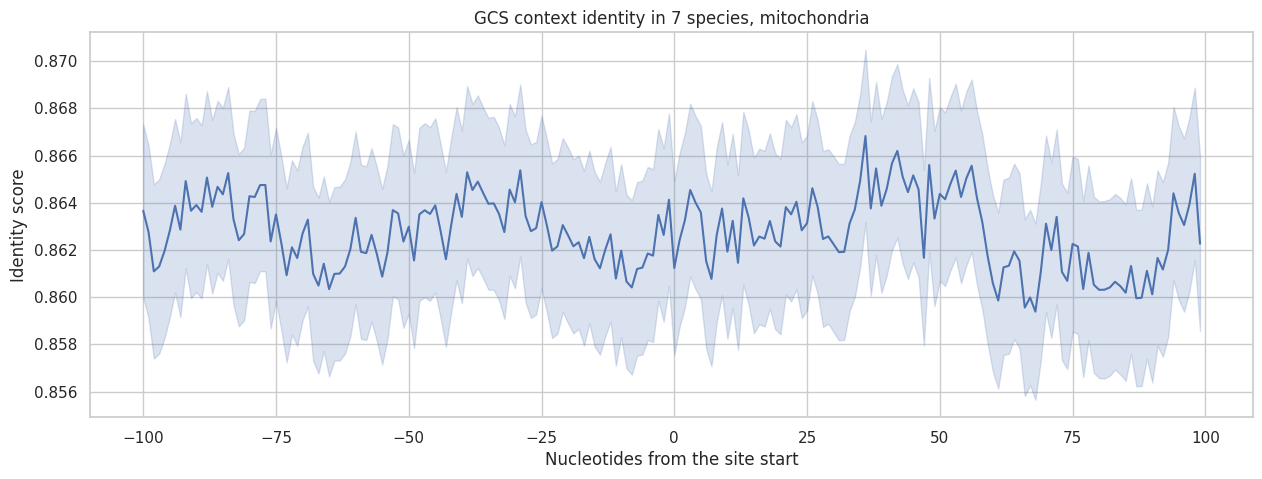

In [9]:
plot_score(id_list, ref_seq, gates, 100, 'GCS context identity in 7 species, mitochondria', 'Identity score', 'se')
plt.savefig('pic_svg/gcs_identity_mt.svg', dpi = 300)

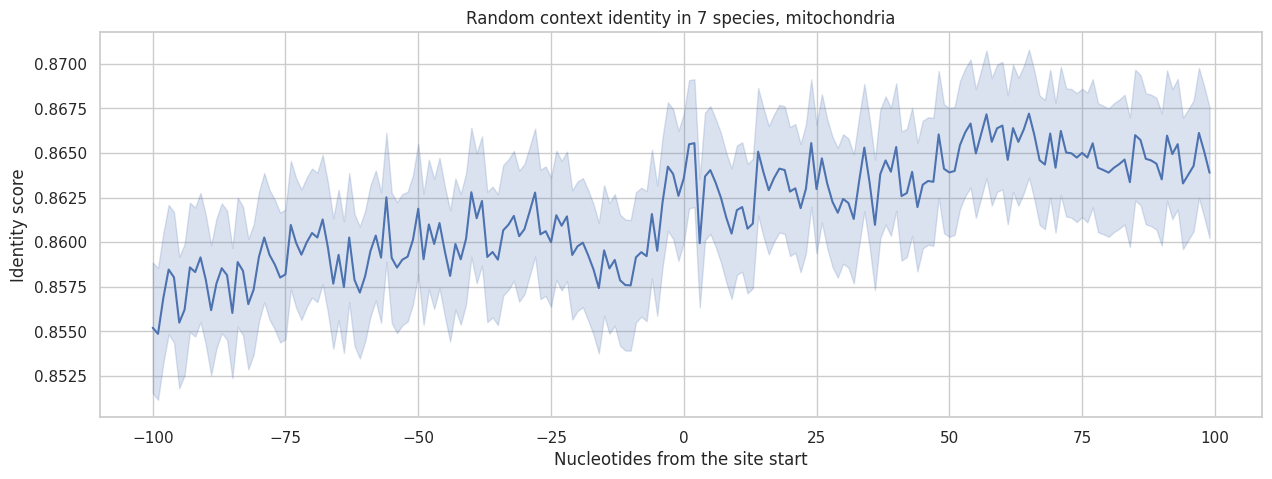

In [10]:
random_gates = get_random_gates(367800, gates, 100, len(gates))
plot_score(id_list, ref_seq, random_gates, 100, 'Random context identity in 7 species, mitochondria', 'Identity score', 'se')
plt.savefig('pic_svg/random_identity_mt.svg', dpi = 300)

In [11]:
random_gates = get_random_gates(367800, gates, 25, len(gates))

gcs_id = mean_score_per_site(id_list, ref_seq, gates, 25)
random_id = mean_score_per_site(id_list, ref_seq, random_gates, 25)

data_id = pd.DataFrame({'id': np.hstack([gcs_id, random_id]), 'type': np.array(['GCS'] * 1789 + ['Random'] * 1789)})

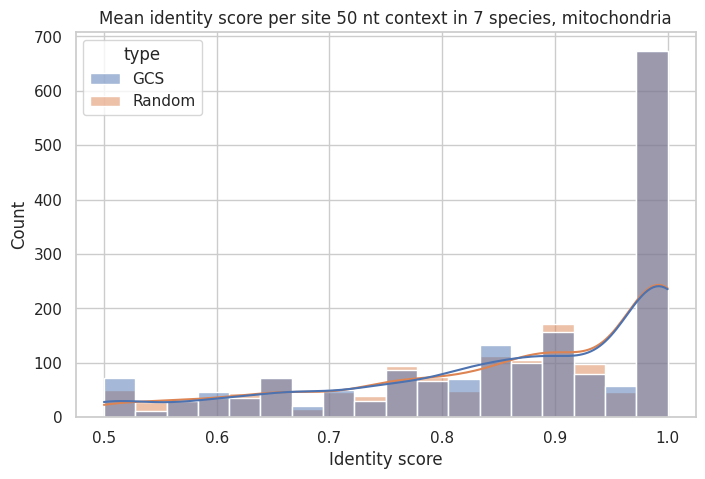

In [12]:
plt.figure(figsize=(8, 5))
ax = sns.histplot(data_id, x='id',hue='type', kde=True)
plt.xlabel('Identity score')
plt.ylabel('Count')
plt.title('Mean identity score per site 50 nt context in 7 species, mitochondria')

plt.savefig('pic_svg/gcs_vs_random_mt.svg', dpi = 300)

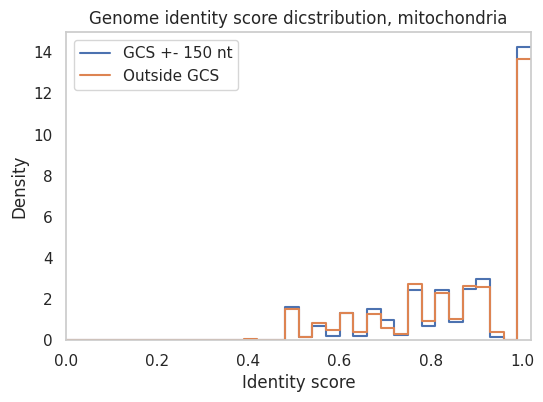

In [13]:
genome_id = np.array(id_list)
gates_id, rest_id = split_score_distribution(genome_id, ref_seq, gates, 150)

plt.figure(figsize=(6, 4))
sns.histplot(gates_id, stat='density', kde=False,  bins=np.arange(0, 1.03, 0.03), label='GCS +- 150 nt', element="step", fill=False)
sns.histplot(rest_id, stat='density', kde=False,  bins=np.arange(0, 1.03, 0.03), label='Outside GCS', element="step", fill=False)

plt.xlabel('Identity score')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1.02)
plt.grid(False)
plt.title('Genome identity score dicstribution, mitochondria')
plt.savefig('pic_svg/gcs_vs_outside_hist_mt_fixed.svg', dpi = 300)


In [14]:
gcs_mt_m = np.mean(gates_id)
rand_mt_m = np.mean(rest_id)
genome_mt = np.mean(genome_id)

wtest_mt_1 = sps.mannwhitneyu(gates_id, rest_id)[1]
wtest_mt_2 = sps.mannwhitneyu(gates_id, genome_id)[1]
wtest_mt_3 = sps.mannwhitneyu(rest_id, genome_id)[1]

kstest_mt_1 = sps.kstest(gates_id, rest_id)[1]
kstest_mt_2 = sps.kstest(gates_id, genome_id)[1]
kstest_mt_3 = sps.kstest(rest_id, genome_id)[1]

# Chloroplasts (13 species)

In [15]:
id_list = []
ref_seq = []
for alignment in AlignIO.parse('cactus_output_plant_cp.maf', 'maf'):
    id_list += compute_identity(alignment)
    ref_seq += str(alignment[0].seq)

id_list = np.array(id_list)
ref_seq = np.array(ref_seq)

gates = []
with open('AP000423.1_Trusted_GCSs_0.01.bed', 'r') as f_bed:
    for line in f_bed:
            start, end = line.strip().split('\t')[1:3]
            gates.append([int(start), int(end)])

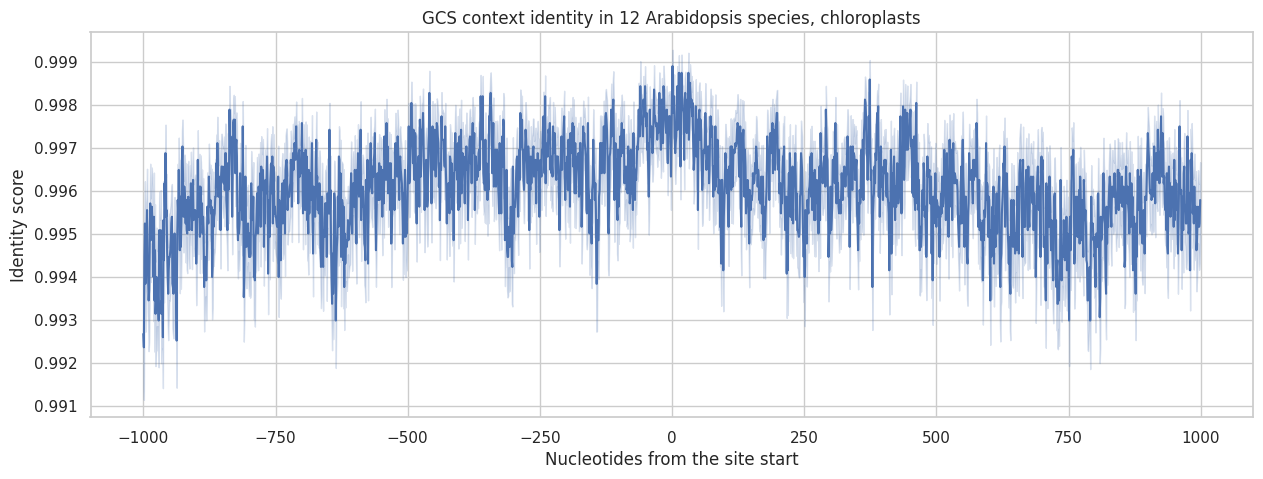

In [16]:
plot_score(id_list, ref_seq, gates, 1000, 'GCS context identity in 12 Arabidopsis species, chloroplasts', 'Identity score', 'se')
plt.savefig('pic_svg/gcs_identity_cp_1000.svg', dpi = 300)

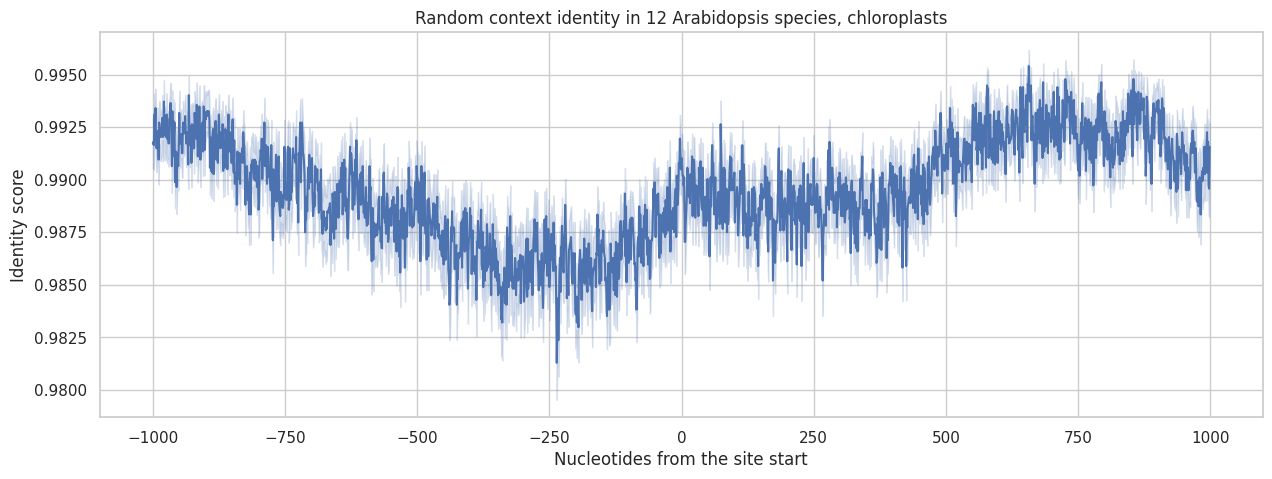

In [17]:
random_gates = get_random_gates(154478, gates, 100, len(gates))
plot_score(id_list, ref_seq, random_gates, 1000, 'Random context identity in 12 Arabidopsis species, chloroplasts', 'Identity score', 'se')
plt.savefig('pic_svg/random_identity_cp_1000.svg', dpi = 300)

In [18]:
random_gates = get_random_gates(154478, gates, 25, len(gates))

gcs_id = mean_score_per_site(id_list, ref_seq, gates, 25)
random_id = mean_score_per_site(id_list, ref_seq, random_gates, 25)

data_id = pd.DataFrame({'id': np.hstack([gcs_id, random_id]), 'type': np.array(['GCS'] * 1087 + ['Random'] * 1087)})

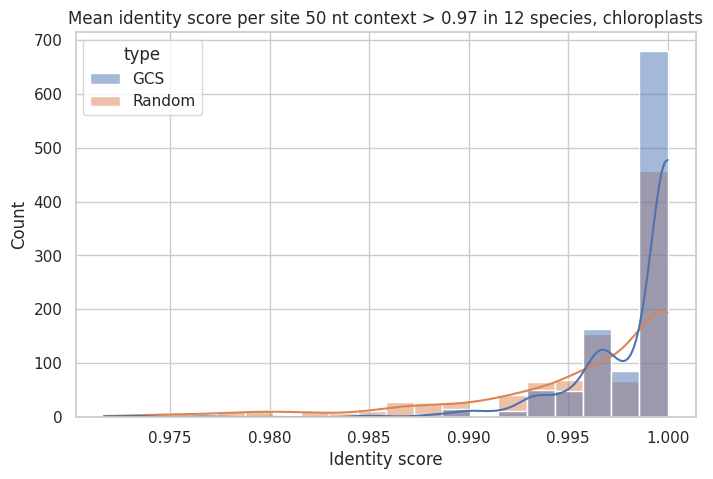

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data_id[data_id['id'] > 0.97], x='id',hue='type', bins=20, kde=True)
plt.xlabel('Identity score')
plt.ylabel('Count')
plt.title('Mean identity score per site 50 nt context > 0.97 in 12 species, chloroplasts')
plt.savefig('pic_svg/gcs_vs_random_cp_zoom.svg', dpi = 300)

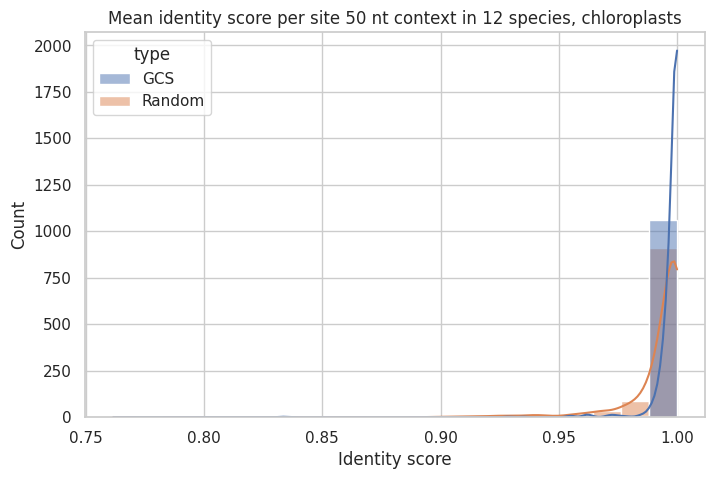

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data_id, x='id',hue='type', bins=20, kde=True)
plt.xlabel('Identity score')
plt.ylabel('Count')
plt.title('Mean identity score per site 50 nt context in 12 species, chloroplasts')
plt.savefig('pic_svg/gcs_vs_random_cp.svg', dpi = 300)

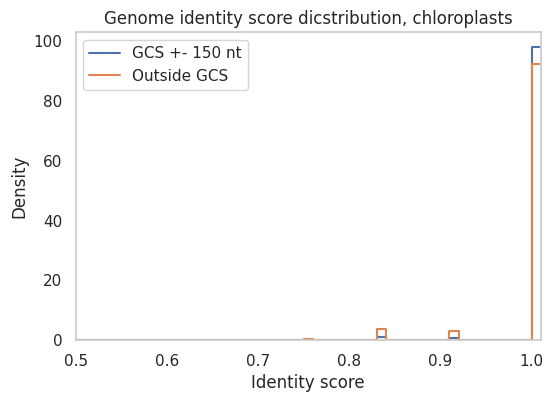

In [21]:
genome_id = np.array(id_list)
gates_id, rest_id = split_score_distribution(genome_id, ref_seq, gates, 150)

plt.figure(figsize=(6, 4))
sns.histplot(gates_id, stat='density', kde=False,  bins=np.arange(0, 1.02, 0.01), label='GCS +- 150 nt', element="step", fill=False)
sns.histplot(rest_id, stat='density', kde=False,  bins=np.arange(0, 1.02, 0.01), label='Outside GCS', element="step", fill=False)
plt.xlabel('Identity score')
plt.ylabel('Density')
plt.legend(loc='upper left')
plt.xlim(0.5, 1.01)
plt.grid(False)
plt.title('Genome identity score dicstribution, chloroplasts')
plt.savefig('pic_svg/gcs_vs_outside_hist_cp_zoom_fixed.svg', dpi = 300)


In [22]:
gcs_cp_m = np.mean(gates_id)
rand_cp_m = np.mean(rest_id)
genome_cp = np.mean(genome_id)

wtest_cp_1 = sps.mannwhitneyu(gates_id, rest_id)[1]
wtest_cp_2 = sps.mannwhitneyu(gates_id, genome_id)[1]
wtest_cp_3 = sps.mannwhitneyu(rest_id, genome_id)[1]

kstest_cp_1 = sps.kstest(gates_id, rest_id)[1]
kstest_cp_2 = sps.kstest(gates_id, genome_id)[1]
kstest_cp_3 = sps.kstest(rest_id, genome_id)[1]

In [23]:
pvals = [wtest_mt_1, wtest_cp_1, wtest_mt_2, wtest_cp_2, wtest_mt_3, wtest_cp_3, 
         kstest_mt_1, kstest_cp_1, kstest_mt_2, kstest_cp_2, kstest_mt_3, kstest_cp_3]
reject, pvals_corrected = multipletests(np.array(pvals), alpha=0.05, method='h', is_sorted=False, returnsorted=False)[:2]

In [24]:
pvals_corrected

array([1.36613536e-022, 0.00000000e+000, 3.12493533e-008, 0.00000000e+000,
       1.50122345e-009, 1.47836365e-190, 2.35028535e-036, 5.52043289e-100,
       5.92551696e-019, 9.03072271e-041, 5.95103857e-014, 7.22861071e-035])

In [25]:
a = pd.DataFrame({
              'GCS mean identity':[gcs_mt_m, gcs_cp_m],
              'Outside mean identity':[rand_mt_m, rand_cp_m],
              'Genome mean identity': [genome_mt, genome_cp],
              'MannWhitneyU Outside vs GCS corrected p-value': [pvals_corrected[0], pvals_corrected[1]],
              'MannWhitneyU Genome vs GCS corrected p-value': [pvals_corrected[2], pvals_corrected[3]],
              'MannWhitneyU Outside vs Genome corrected p-value': [pvals_corrected[4], pvals_corrected[5]],
              'KStest Genome vs GCS corrected p-value': [pvals_corrected[6], pvals_corrected[7]],
              'KStest Outside vs GCS corrected p-value': [pvals_corrected[8], pvals_corrected[9]],
              'KStest Outside vs Genome corrected p-value': [pvals_corrected[10], pvals_corrected[11]],

              }, index=['Mitochondria', 'Chloroplasts'])
a.to_csv('identity_stats.csv', index=False)


In [26]:
a

,GCS mean identity,Outside mean identity,Genome mean identity,MannWhitneyU Outside vs GCS corrected p-value,MannWhitneyU Genome vs GCS corrected p-value,MannWhitneyU Outside vs Genome corrected p-value,KStest Genome vs GCS corrected p-value,KStest Outside vs GCS corrected p-value,KStest Outside vs Genome corrected p-value
Mitochondria,0.862614,0.857703,0.860651,1.366135e-22,3.124935e-08,1.501223e-09,2.350285e-36,5.925517e-19,5.951039e-14
Chloroplasts,0.996898,0.988532,0.993696,0.000000e+00,0.000000e+00,1.478364e-190,5.520433e-100,9.030723e-41,7.228611e-35
